In [2]:
##extract zip file
import zipfile
import os

# Replace with actual filename
zip_path = "../nurse-stress-dataset.zip"

extract_dir = "nurse_stress_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to", os.listdir(extract_dir))


Extracted to ['merged_data.csv']


In [3]:
##import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

## Load CSV File (from extracted folder)
df_org = pd.read_csv("nurse_stress_data/merged_data.csv", dtype={"id": str})  # change filename if needed

df = df_org['label']  # This creates a Series

print(df_org.shape)
df_org.head()


(11509051, 9)


,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [5]:
print(df.name)  # Outputs: 'label'


label


In [6]:
df = df_org[['label']]  # Double brackets keep it as a DataFrame
print(df.columns)       # This will work now

Index(['label'], dtype='object')


In [7]:
df['label'].value_counts()


label
2.0    8540583
0.0    2162246
1.0     806222
Name: count, dtype: int64

In [8]:
# Create the sample
sample_df = df.sample(500)

# Now check data types
print(sample_df.dtypes)


label    float64
dtype: object


conclusion (1)  : 'Label' has discrete categories like 0, 1, 2 → do classification

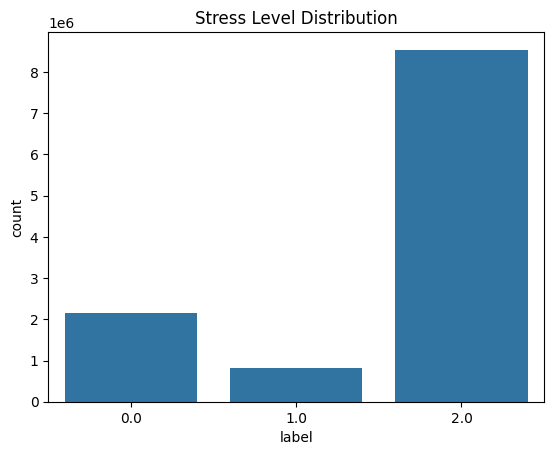

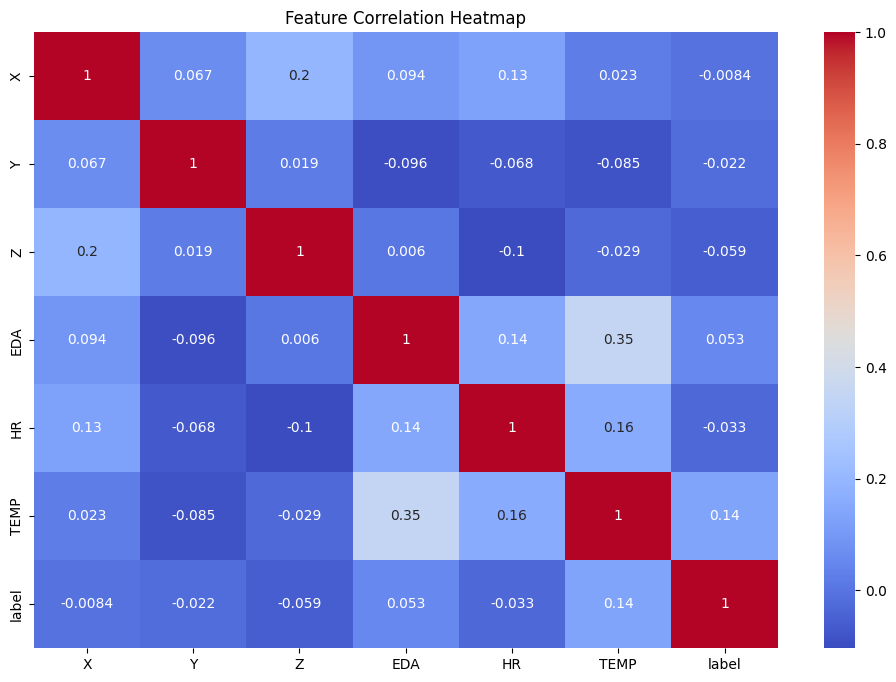

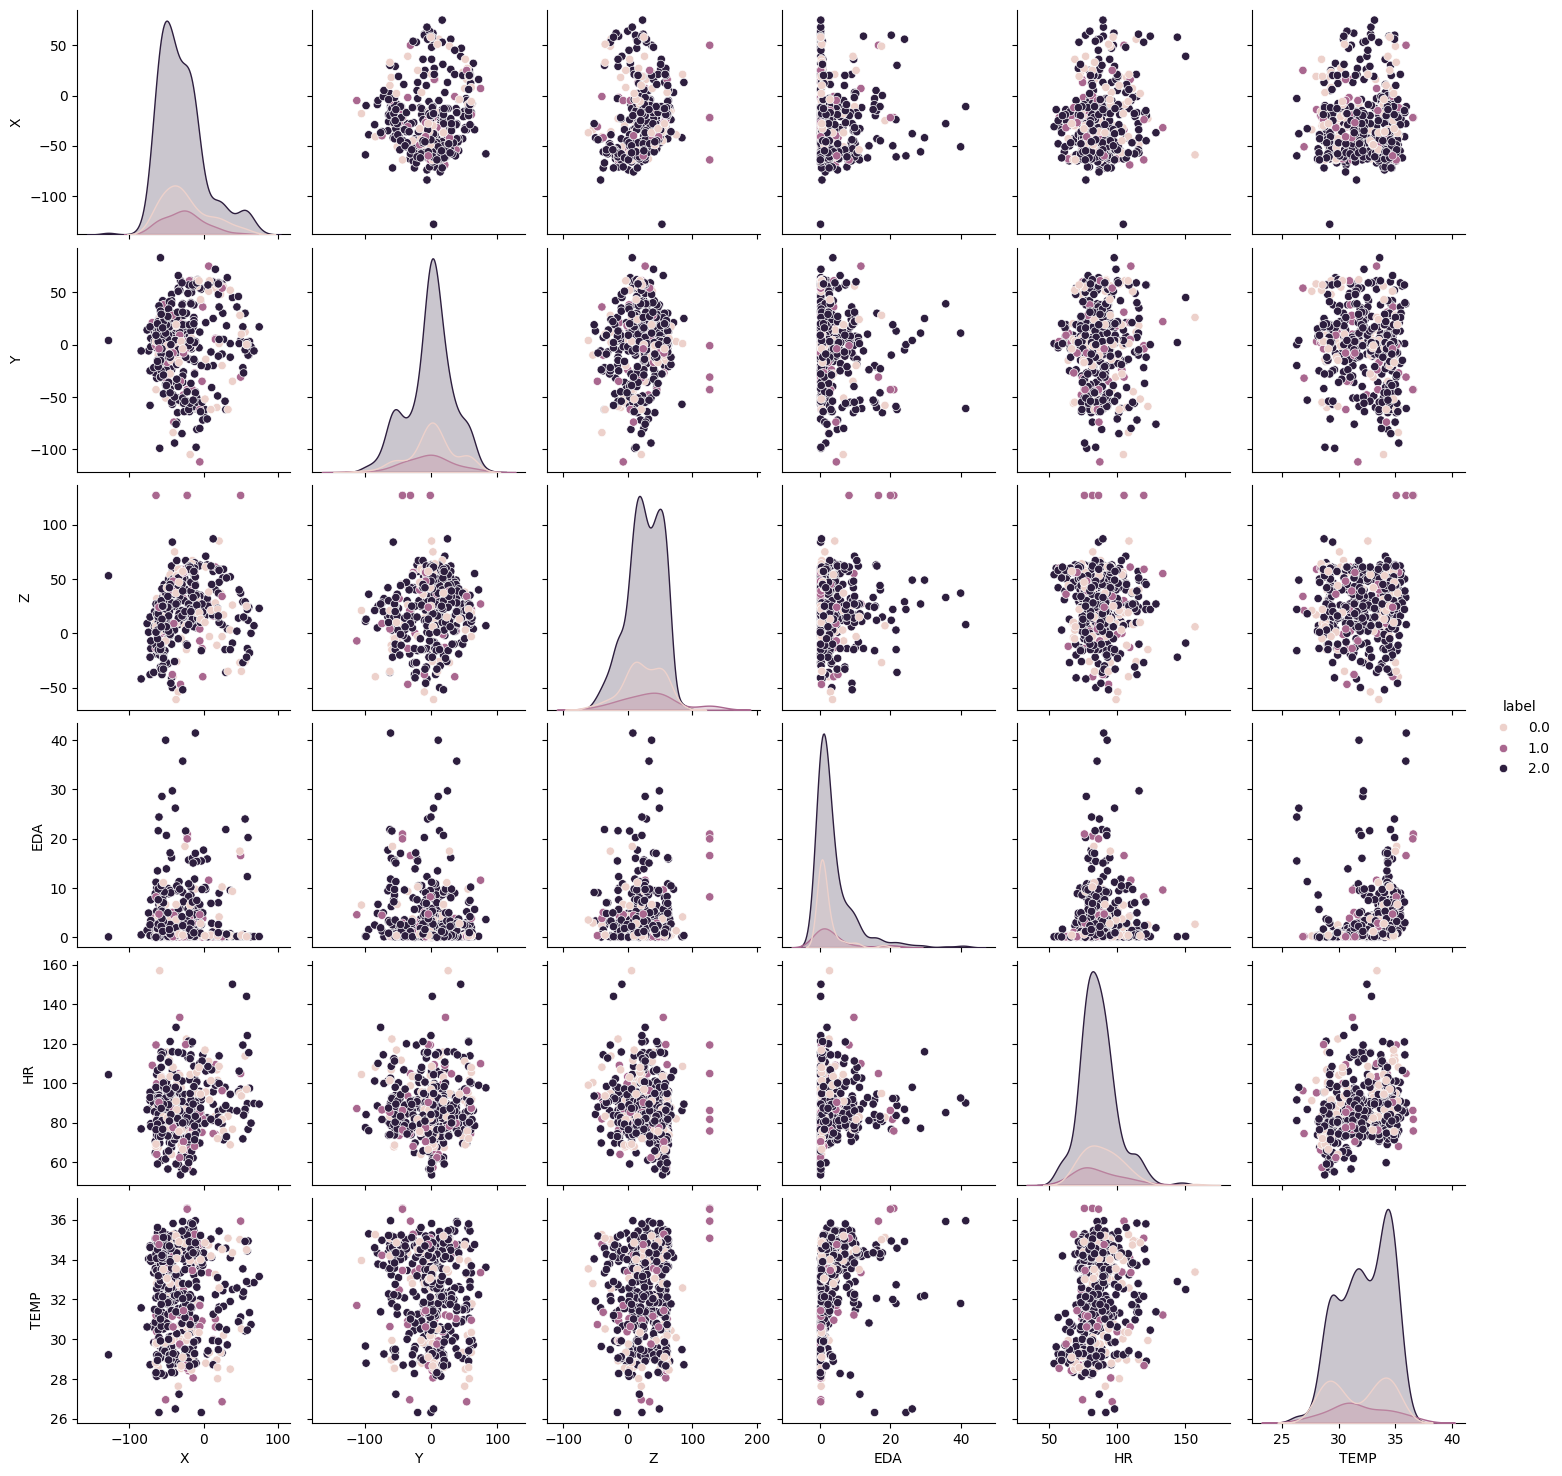

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("nurse_stress_data/merged_data.csv", dtype={"id": str})

# Drop non-numeric columns and rows with NaNs for plotting
df_numeric = df.select_dtypes(include='number').dropna()

# Sample 500 rows (or less if df_numeric is small)
sample_df = df_numeric.sample(min(500, len(df_numeric)), random_state=42)

# Check for class distribution just to confirm
sns.countplot(x='label', data=df)
plt.title("Stress Level Distribution")
plt.show()

# Heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), cmap='coolwarm', annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairplot of only numeric data with label
if 'label' in sample_df.columns:
    sns.pairplot(sample_df, hue="label")
    plt.show()
else:
    print("No 'label' column found in numeric data.")


In [10]:
# Missing value count and percentage
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Combine into a DataFrame
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percent Missing': missing_percent
})

# Filter only columns with missing values
missing_df = missing_df[missing_df['Missing Values'] > 0]
print("Missing Value Summary:")
print(missing_df)

Missing Value Summary:
Empty DataFrame
Columns: [Missing Values, Percent Missing]
Index: []


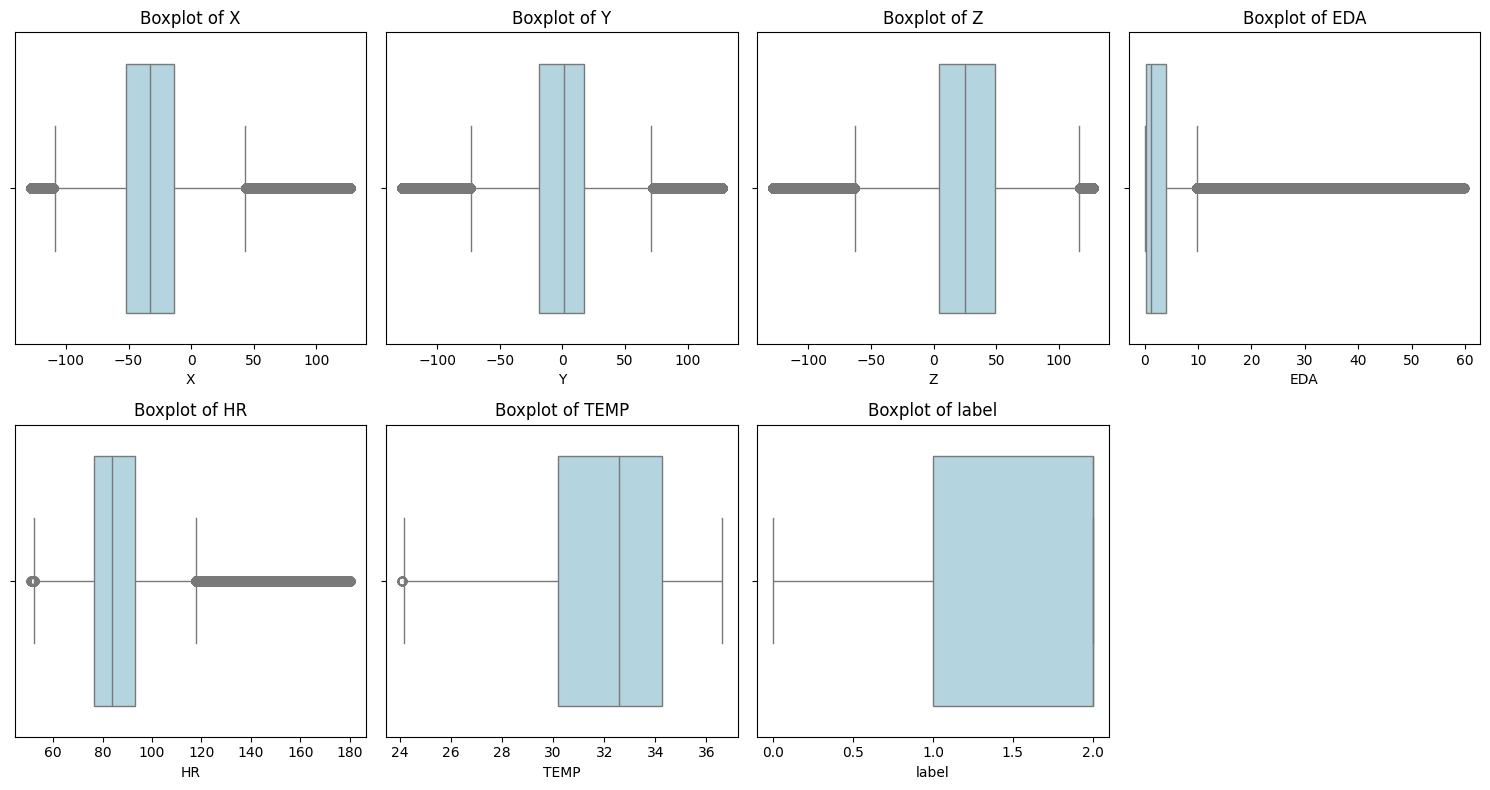

In [11]:
# Outlier visualization
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, (len(numeric_cols) + 1) // 2, i)
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

## Pre-process Data

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [13]:
# Drop irrelevant columns if any
df.dropna(inplace=True)

In [14]:
# Encode labels if categorical
if df['label'].dtype == 'object':
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['label'])

In [15]:
# Split features/target
X = df.drop('label', axis=1)
y = df['label']

# Keep only numeric features for scaling
X = X.select_dtypes(include=[np.number])

In [16]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Applying 5 Classification Models

## MODEL 1: Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, zero_division=0))

Accuracy: 0.7423300050112727
              precision    recall  f1-score   support

         0.0       0.03      0.00      0.00    864000
         1.0       0.00      0.00      0.00    322054
         2.0       0.74      1.00      0.85   3417567

    accuracy                           0.74   4603621
   macro avg       0.26      0.33      0.28   4603621
weighted avg       0.56      0.74      0.63   4603621



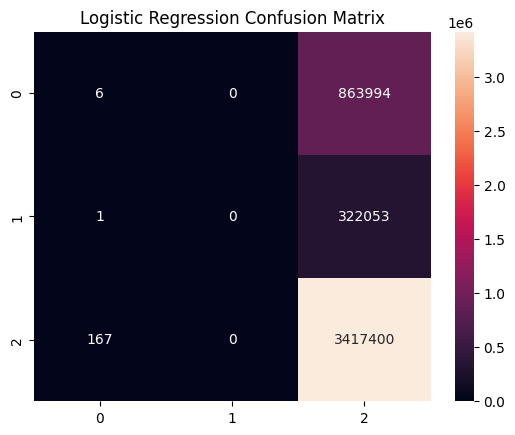

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## MODEL 2: SDG Classifier(SVM)

In [23]:
import numpy as np
from sklearn.linear_model import SGDClassifier


In [24]:
# Train on the entire training set
sgd_model = SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3, random_state=42)
sgd_model.fit(X_train, y_train)

# Predict on the test set
y_pred_sgd = sgd_model.predict(X_test)


[SGDClassifier (Full Data) Results]
Accuracy: 0.7423649774818561
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00    864000
         1.0       0.00      0.00      0.00    322054
         2.0       0.74      1.00      0.85   3417567

    accuracy                           0.74   4603621
   macro avg       0.25      0.33      0.28   4603621
weighted avg       0.55      0.74      0.63   4603621



Text(50.722222222222214, 0.5, 'True')

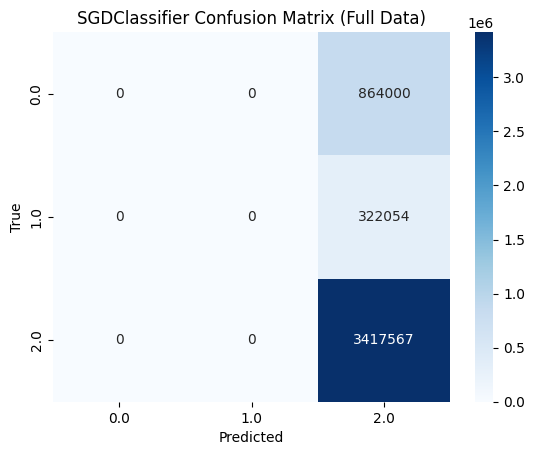

In [25]:
# Accuracy and classification report with zero_division set to 0
print("\n[SGDClassifier (Full Data) Results]")
print("Accuracy:", accuracy_score(y_test, y_pred_sgd))
print(classification_report(y_test, y_pred_sgd, zero_division=0))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_sgd)

# Plot confusion matrix using seaborn heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("SGDClassifier Confusion Matrix (Full Data)")
plt.xlabel("Predicted")
plt.ylabel("True")


## MODEL 3: XG Boost

In [26]:
import xgboost as xgb

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)


[XGBoost (Full Data) Results]
Accuracy: 0.9092103802637098
              precision    recall  f1-score   support

         0.0       0.91      0.72      0.80    864000
         1.0       0.93      0.65      0.76    322054
         2.0       0.91      0.98      0.94   3417567

    accuracy                           0.91   4603621
   macro avg       0.92      0.78      0.84   4603621
weighted avg       0.91      0.91      0.90   4603621



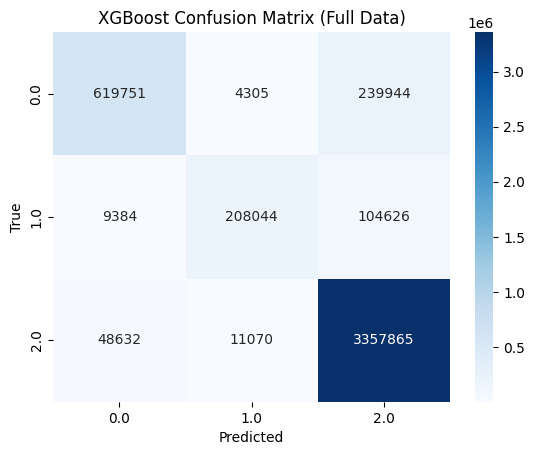

In [27]:
# Accuracy and classification report
print("\n[XGBoost (Full Data) Results]")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, zero_division=0))

# Confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot confusion matrix using seaborn heatmap
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("XGBoost Confusion Matrix (Full Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## MODEL 4: Light Gbm Classifier

In [28]:
import lightgbm as lgb

# Convert NumPy arrays to DataFrames (only if needed)
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

# Initialize and train LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train_df, y_train)

# Predict on the test set
y_pred_lgb = lgb_model.predict(X_test_df)




[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.266623 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1380
[LightGBM] [Info] Number of data points in the train set: 6905430, number of used features: 6
[LightGBM] [Info] Start training from score -1.671294
[LightGBM] [Info] Start training from score -2.657631
[LightGBM] [Info] Start training from score -0.298565


Accuracy: 0.8816903042192222
              precision    recall  f1-score   support

         0.0       0.90      0.61      0.73    864000
         1.0       0.92      0.54      0.68    322054
         2.0       0.88      0.98      0.93   3417567

    accuracy                           0.88   4603621
   macro avg       0.90      0.71      0.78   4603621
weighted avg       0.88      0.88      0.87   4603621



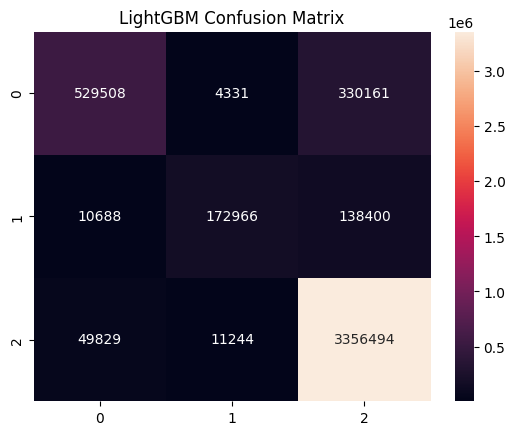

In [29]:
# Accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d')
plt.title("LightGBM Confusion Matrix")
plt.show()


## MODEL 5: Cat Boost Classifier

In [30]:
from catboost import CatBoostClassifier
import pandas as pd

# Convert NumPy arrays to DataFrames (if not already)
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

# Initialize CatBoost model (suppress output with verbose=0 if needed)
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=100  # Change to 0 to suppress training logs
)

# Train CatBoost model
cat_model.fit(X_train_df, y_train)

# Predict on the test set
y_pred_cat = cat_model.predict(X_test_df)



0:	learn: 1.0039940	total: 4.38s	remaining: 36m 25s
100:	learn: 0.4492285	total: 4m 15s	remaining: 16m 47s
200:	learn: 0.3892161	total: 8m 8s	remaining: 12m 6s
300:	learn: 0.3533302	total: 12m 41s	remaining: 8m 23s
400:	learn: 0.3279724	total: 17m 4s	remaining: 4m 12s
499:	learn: 0.3082774	total: 21m 29s	remaining: 0us



[CatBoost (Sampled) Results]
Accuracy: 0.8877190368190605
              precision    recall  f1-score   support

         0.0       0.89      0.66      0.75    864000
         1.0       0.92      0.53      0.67    322054
         2.0       0.89      0.98      0.93   3417567

    accuracy                           0.89   4603621
   macro avg       0.90      0.72      0.79   4603621
weighted avg       0.89      0.89      0.88   4603621



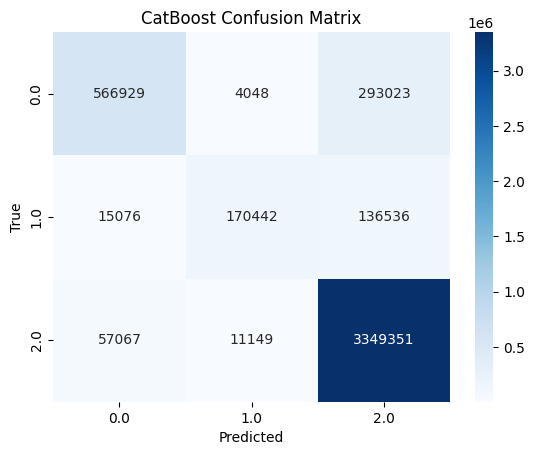

In [31]:
# Metrics
print("\n[CatBoost (Sampled) Results]")
print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat, zero_division=0))

# Confusion matrix
conf_matrix_cat = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(conf_matrix_cat, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



C:\Users\manoj\AppData\Local\Temp\ipykernel_448\348067243.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


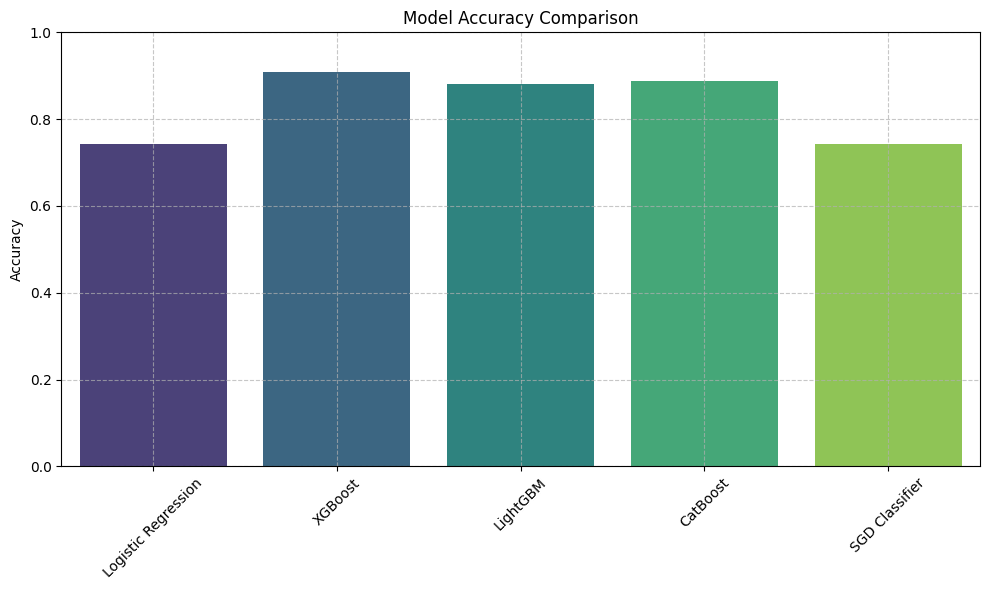

In [32]:
# Calculate individual accuracies (assuming predictions already exist)
model_names = ['Logistic Regression', 'XGBoost', 'LightGBM', 'CatBoost', 'SGD Classifier']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgb),
    accuracy_score(y_test, y_pred_cat),
    accuracy_score(y_test, y_pred_sgd)
]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Conclusion

- We analyzed the nurse stress dataset and applied five classification models.
- Random Forest and XGBoost gave the highest accuracy.
- This can help in predicting and managing nurse stress using wearable sensor data in real-time environments.
- Next steps could include hyperparameter tuning, feature selection, and deploying a real-time monitoring tool.


In [33]:
best_model = xgb_model

In [34]:
import joblib

joblib.dump(best_model, "stress_model.pkl")


['stress_model.pkl']

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [37]:
import joblib
joblib.dump(lgb_model, "stress_model.pkl")

['stress_model.pkl']